#Step 1: Load the Dataset and Inspect

In [ ]:
# Loading required libraries
library(tidyverse)
library(lubridate)

# Loading the dataset
data <- read.csv("Electric Car Sales by Model in USA.csv")

# Inspecting structure and first few rows of the dataset
str(data)
head(data)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


'data.frame':	57 obs. of  99 variables:
 $ Make    : chr  "Chevrolet" "Toyota" "Nissan" "Tesla" ...
 $ Model   : chr  "Volt" "Prius PHV" "Leaf" "Model S" ...
 $ Logo    : chr  "https://www.carlogos.org/logo/Chevrolet-logo-2013-2560x1440.png" "https://www.carlogos.org/logo/Toyota-logo-1989-2560x1440.png" "https://www.carlogos.org/logo/Nissan-logo-2013-1440x900.png" "https://www.carlogos.org/logo/Tesla-logo-2003-2500x2500.png" ...
 $ janv.12 : num  603 0 676 0 0 2 36 0 0 0 ...
 $ Feb.2012: num  1626 21 1154 NA NA ...
 $ mars.12 : num  3915 912 1733 NA NA ...
 $ Apr.2012: num  5377 2566 2103 NA NA ...
 $ May.2012: num  7057 3652 2613 NA NA ...
 $ juin.12 : num  8817 4347 3148 12 NA ...
 $ juil.12 : num  10666 5035 3543 31 NA ...
 $ Aug.2012: num  13497 6082 4228 74 NA ...
 $ sept.12 : num  16348 7734 5212 160 NA ...
 $ oct.12  : num  19309 9623 6791 460 144 ...
 $ nov.12  : num  20828 11389 8330 860 1403 ...
 $ Dec.2012: num  23461 12750 9819 2650 2374 ...
 $ janv.13 : num  24601 13624 10

,Make,Model,Logo,janv.12,Feb.2012,mars.12,Apr.2012,May.2012,juin.12,juil.12,⋯,mars.19,Apr.2019,May.2019,juin.19,juil.19,Aug.2019,sept.19,oct.19,nov.19,Dec.2019
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Chevrolet,Volt,https://www.carlogos.org/logo/Chevrolet-logo-2013-2560x1440.png,603,1626,3915,5377,7057,8817,10666,⋯,146667,147072,"147,48","147,813","148,063","148,337","148,687","148,757","148,907","149,057"
2,Toyota,Prius PHV,https://www.carlogos.org/logo/Toyota-logo-1989-2560x1440.png,0,21,912,2566,3652,4347,5035,⋯,42345,42345,42345,42345,42345,42345,42345,42345,42345,42345
3,Nissan,Leaf,https://www.carlogos.org/logo/Nissan-logo-2013-1440x900.png,676,1154,1733,2103,2613,3148,3543,⋯,122534,123485,"124,701","125,857","126,795","127,912","128,96","129,847","130,987","132,214"
4,Tesla,Model S,https://www.carlogos.org/logo/Tesla-logo-2003-2500x2500.png,0,NA,NA,NA,NA,12,31,⋯,147517,148342,"149,367","151,117","152,092","153,142","154,242","154,992","156,492","157,992"
5,Ford,C-Max Energi,https://www.carlogos.org/logo/Ford-logo-2003-1366x768.png,0,NA,NA,NA,NA,NA,NA,⋯,42231,42231,42231,42231,42231,42231,42231,42231,42231,42231
6,Ford,Focus Electric,https://www.carlogos.org/logo/Ford-logo-2003-1366x768.png,2,2,2,2,8,97,135,⋯,9242,9242,9242,9242,9242,9242,9242,9242,9242,9242


# Step 2: Reshaping and Summarizing the Data
Reshaping the dataset into a long format to work with it as a time series. Summarizing the sales data by month across all models.

Step 2.1: Fix Data Types and Reshape

In [ ]:
# Converting all columns related to sales into numeric, replacing commas and characters
sales_cols <- grep("janv.|Feb.|mars.|Apr.|May.|juin.|juil.|Aug.|sept.|oct.|nov.|Dec.", colnames(data), value = TRUE)

# Removing commas and convert to numeric
data[sales_cols] <- lapply(data[sales_cols], function(x) as.numeric(gsub(",", "", x)))

# Reshaping the data into long format
sales_long <- data %>%
  pivot_longer(cols = all_of(sales_cols),
               names_to = "Month",
               values_to = "Sales")

# Summarizing total sales by month
monthly_sales <- sales_long %>%
  group_by(Month) %>%
  summarize(Total_Sales = sum(Sales, na.rm = TRUE))

# Showing the first few rows of the summarized data
head(monthly_sales)

Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”


Month,Total_Sales
<chr>,<dbl>
Apr.2012,10263
Apr.2013,77708
Apr.2014,181369
Apr.2015,304995
Apr.2016,427023
Apr.2017,602553


#Step 3: Convert to Time Series Object

In [ ]:
# Checking unique values in the Month column
unique(monthly_sales$Month)

 [1] "2012-02-01 UTC" "2012-04-01 UTC" "2012-05-01 UTC" "2012-08-01 UTC"
 [5] "2012-09-01 UTC" "2012-10-01 UTC" "2012-11-01 UTC" "2012-12-01 UTC"
 [9] "2013-02-01 UTC" "2013-04-01 UTC" "2013-05-01 UTC" "2013-08-01 UTC"
[13] "2013-09-01 UTC" "2013-10-01 UTC" "2013-11-01 UTC" "2013-12-01 UTC"
[17] "2014-02-01 UTC" "2014-04-01 UTC" "2014-05-01 UTC" "2014-08-01 UTC"
[21] "2014-09-01 UTC" "2014-10-01 UTC" "2014-11-01 UTC" "2014-12-01 UTC"
[25] "2015-02-01 UTC" "2015-04-01 UTC" "2015-05-01 UTC" "2015-08-01 UTC"
[29] "2015-09-01 UTC" "2015-10-01 UTC" "2015-11-01 UTC" "2015-12-01 UTC"
[33] "2016-02-01 UTC" "2016-04-01 UTC" "2016-05-01 UTC" "2016-08-01 UTC"
[37] "2016-09-01 UTC" "2016-10-01 UTC" "2016-11-01 UTC" "2016-12-01 UTC"
[41] "2017-02-01 UTC" "2017-04-01 UTC" "2017-05-01 UTC" "2017-08-01 UTC"
[45] "2017-09-01 UTC" "2017-10-01 UTC" "2017-11-01 UTC" "2017-12-01 UTC"
[49] "2018-02-01 UTC" "2018-04-01 UTC" "2018-05-01 UTC" "2018-08-01 UTC"
[53] "2018-09-01 UTC" "2018-10-01 UTC" "2018-11-01 

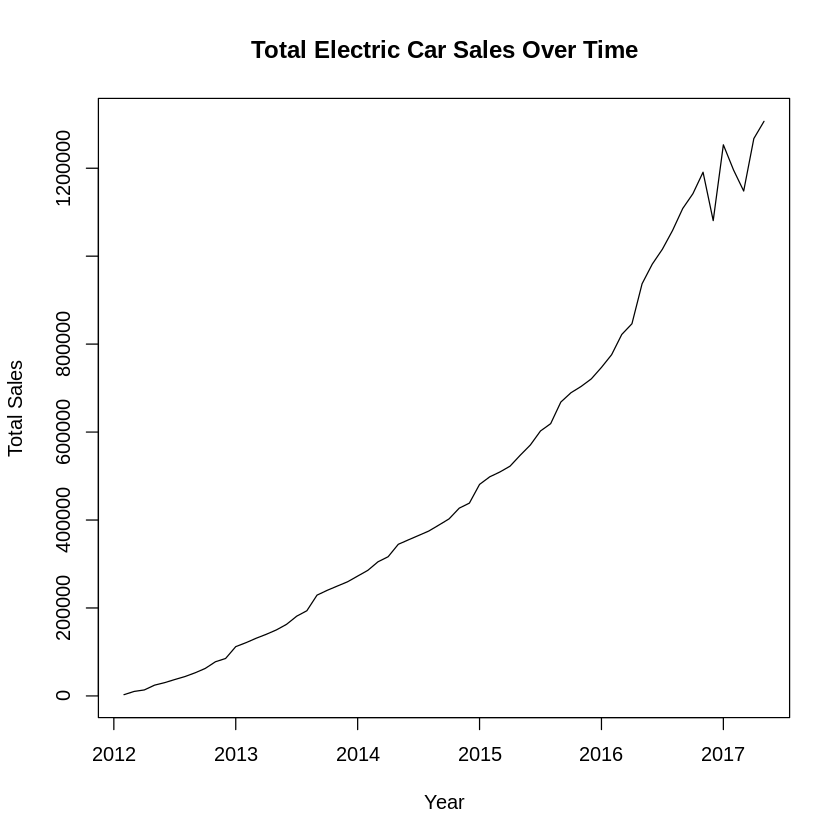

In [ ]:
# Removing rows with NA in Month
monthly_sales <- monthly_sales %>%
  filter(!is.na(Month))

# Converting to a time series object
sales_ts <- ts(monthly_sales$Total_Sales,
               start = c(year(min(monthly_sales$Month)), month(min(monthly_sales$Month))),
               frequency = 12)

# Plotting the time series
plot(sales_ts,
     main = "Total Electric Car Sales Over Time",
     xlab = "Year",
     ylab = "Total Sales")

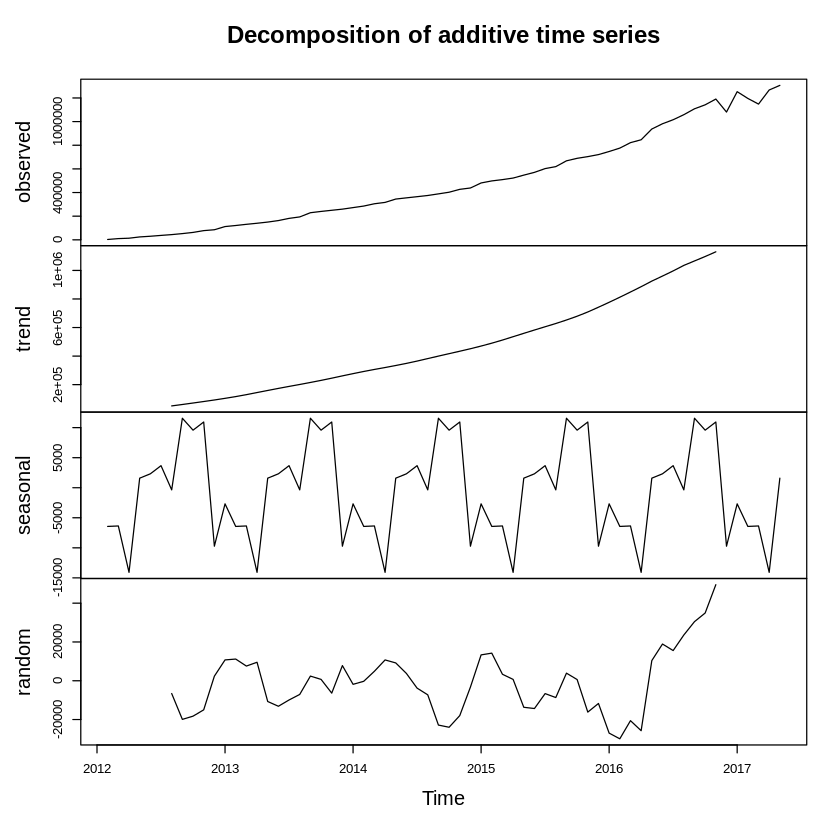

In [ ]:
# Decomposing time series into trend, seasonality, and residuals
decomposed <- decompose(sales_ts)

# Plotting decomposed components
plot(decomposed)

In [ ]:
install.packages("tseries")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’




In [ ]:
library(tseries)

# Performing Augmented Dickey-Fuller test
adf_test <- adf.test(sales_ts)

# Printing test results
adf_test

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 




	Augmented Dickey-Fuller Test

data:  sales_ts
Dickey-Fuller = -0.87145, Lag order = 3, p-value = 0.9506
alternative hypothesis: stationary


The ADF test result shows a high p-value (0.9506), which indicates that the null hypothesis (the time series is non-stationary) cannot be rejected. This means the time series is non-stationary, and we need to transform it to achieve stationarity before fitting ARIMA models.

#Step 6: Differencing the Time Series


	Augmented Dickey-Fuller Test

data:  diff_sales_ts
Dickey-Fuller = -2.4552, Lag order = 3, p-value = 0.3906
alternative hypothesis: stationary


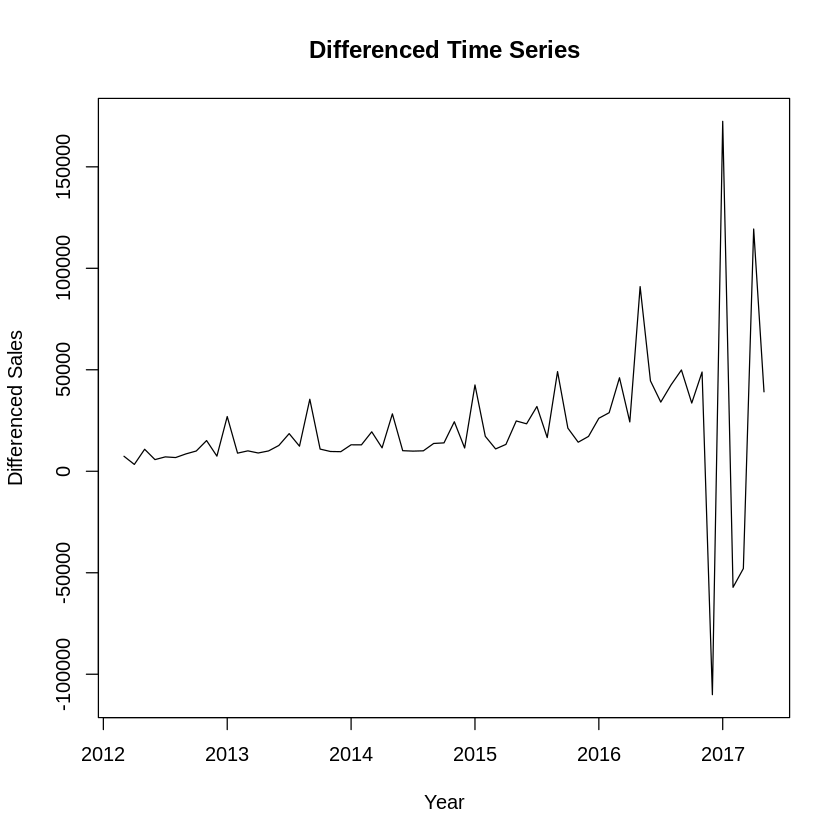

In [ ]:
# first-order differencing
diff_sales_ts <- diff(sales_ts)

# Performing ADF test on differenced data
adf_test_diff <- adf.test(diff_sales_ts)

# Printing the test results
adf_test_diff

# Plotting the differenced time series
plot(diff_sales_ts,
     main = "Differenced Time Series",
     xlab = "Year",
     ylab = "Differenced Sales")

The ADF test on the differenced series still shows a high p-value (0.3906), indicating that the series might still not be stationary. To address this, we can try second-order differencing or inspect further for seasonality.

Step 6.1: Second-Order Differencing

Warning message in adf.test(diff2_sales_ts):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  diff2_sales_ts
Dickey-Fuller = -5.3439, Lag order = 3, p-value = 0.01
alternative hypothesis: stationary


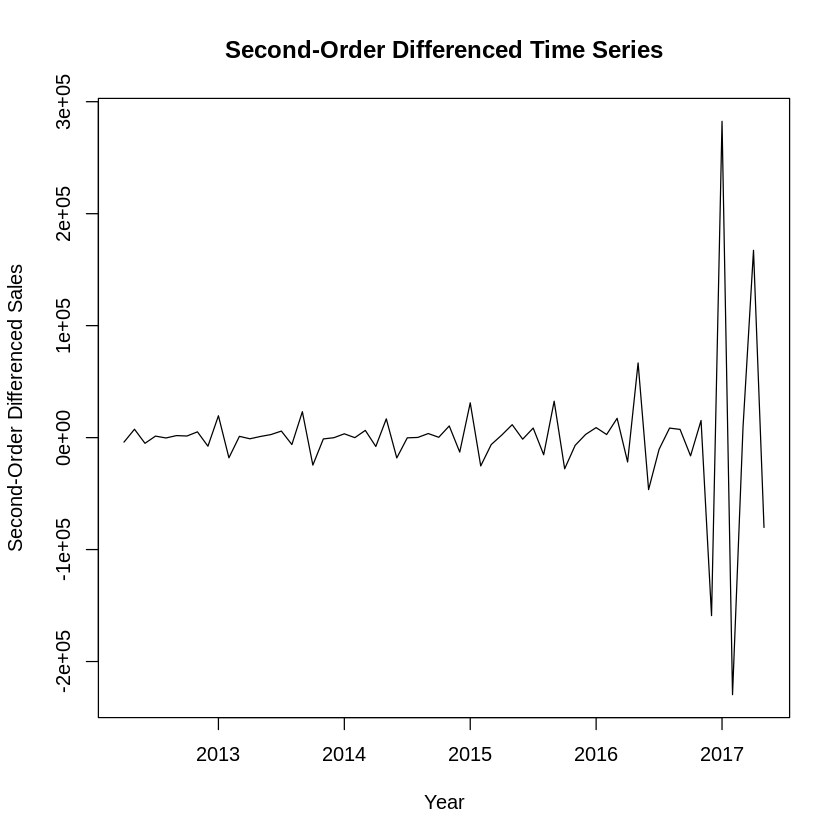

In [ ]:
# Second-order differencing
diff2_sales_ts <- diff(diff_sales_ts)

# Performing ADF test on second-order differenced data
adf_test_diff2 <- adf.test(diff2_sales_ts)

# Printing test results
adf_test_diff2

# Plotting second-order differenced time series
plot(diff2_sales_ts,
     main = "Second-Order Differenced Time Series",
     xlab = "Year",
     ylab = "Second-Order Differenced Sales")

The second-order differencing has successfully made the series stationary, as evidenced by the ADF test result (Dickey-Fuller = -5.3439, p-value < 0.01). This means we can now proceed to fit ARIMA or SARIMA models for forecasting.

#Step 7: Fit an ARIMA Model

In [ ]:
install.packages("forecast")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’




In [ ]:
library(forecast)

# Fitting ARIMA model to original time series
arima_model <- auto.arima(sales_ts, seasonal = TRUE)

# Summary of the ARIMA model
summary(arima_model)

Series: sales_ts 
ARIMA(2,2,2) 

Coefficients:
          ar1      ar2      ma1     ma2
      -0.6130  -0.6427  -0.7674  0.8185
s.e.   0.1347   0.1319   0.1224  0.1190

sigma^2 = 749440788:  log likelihood = -721.69
AIC=1453.38   AICc=1454.45   BIC=1464.01

Training set error measures:
                   ME    RMSE      MAE       MPE     MAPE       MASE       ACF1
Training set 1402.886 26061.1 15467.31 0.4298246 3.811731 0.06094694 -0.1035427

The ARIMA(2,2,2) model has been successfully fitted to the data. Here's a breakdown of the key results:

ARIMA Parameters:

*   AR (Auto-regressive): 2
*   Differencing (d): 2 (second-order differencing was required)
* MA (Moving Average): 2



Model Coefficients:
* AR1 = -0.6130, AR2 = -0.6427
* MA1 = -0.7674, MA2 = 0.8185

Model Fit Metrics:
* AIC = 1453.38 (used for model comparison; lower is better).
* RMSE = 26061.1 (Root Mean Squared Error, indicates the error magnitude).

#Step 8: Forecast Future Sales

         Point Forecast   Lo 80   Hi 80   Lo 95   Hi 95
Jun 2017        1279077 1243993 1314161 1225421 1332733
Jul 2017        1380524 1339253 1421796 1317405 1443644
Aug 2017        1445756 1385249 1506263 1353218 1538293
Sep 2017        1450301 1353233 1547370 1301848 1598754
Oct 2017        1515326 1390232 1640419 1324012 1706640
Nov 2017        1582279 1426047 1738511 1343343 1821215
Dec 2017        1609179 1412462 1805895 1308327 1910031
Jan 2018        1659393 1423011 1895775 1297878 2020908
Feb 2018        1721058 1444162 1997953 1297583 2144532
Mar 2018        1760719 1438074 2083363 1267276 2254161
Apr 2018        1806509 1436599 2176418 1240781 2372236
May 2018        1862684 1444685 2280683 1223409 2501958

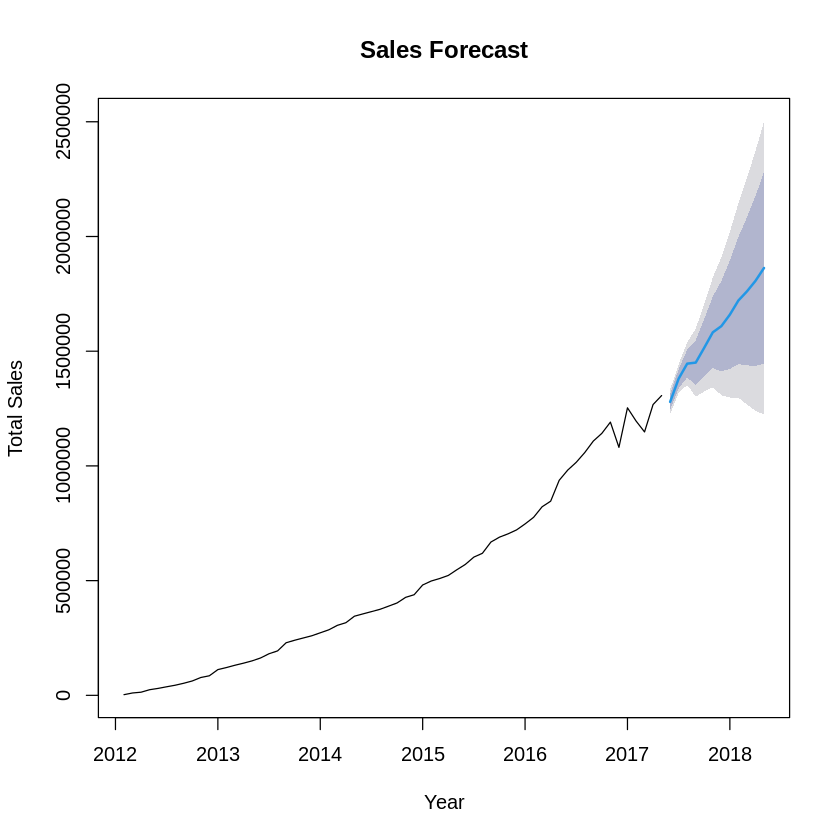

In [ ]:
# Forecasting the next 12 months
sales_forecast <- forecast(arima_model, h = 12)

# Plotting the forecast
plot(sales_forecast,
     main = "Sales Forecast",
     xlab = "Year",
     ylab = "Total Sales")

# Printing the forecasted values
sales_forecast

Key Observations:
* Point Forecast: The solid blue line represents the predicted sales for each month.
 * Example: Predicted sales for Jun 2017 = 1,279,077 units.
* Confidence Intervals:
 * 80% Interval (Light Shaded Area): Indicates a higher probability of the true sales value falling within this range.
 * 95% Interval (Darker Shaded Area): Represents a wider range, giving more conservative estimates of uncertainty.
* Insights:
 * Sales are expected to grow steadily over time.
 * The range of uncertainty widens for forecasts further into the future, as indicated by the increasing spread of the confidence intervals.

# Step 9: Residual Diagnostics


	Ljung-Box test

data:  Residuals from ARIMA(2,2,2)
Q* = 10.047, df = 9, p-value = 0.3467

Model df: 4.   Total lags used: 13



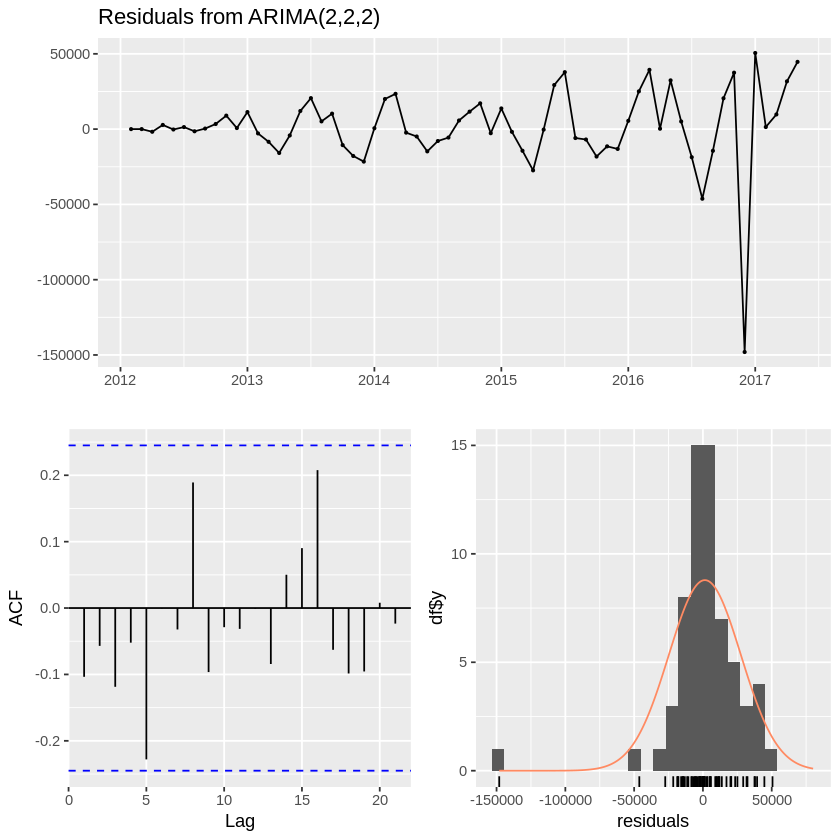


	Box-Ljung test

data:  residuals_plot
X-squared = 9.3807, df = 10, p-value = 0.4964


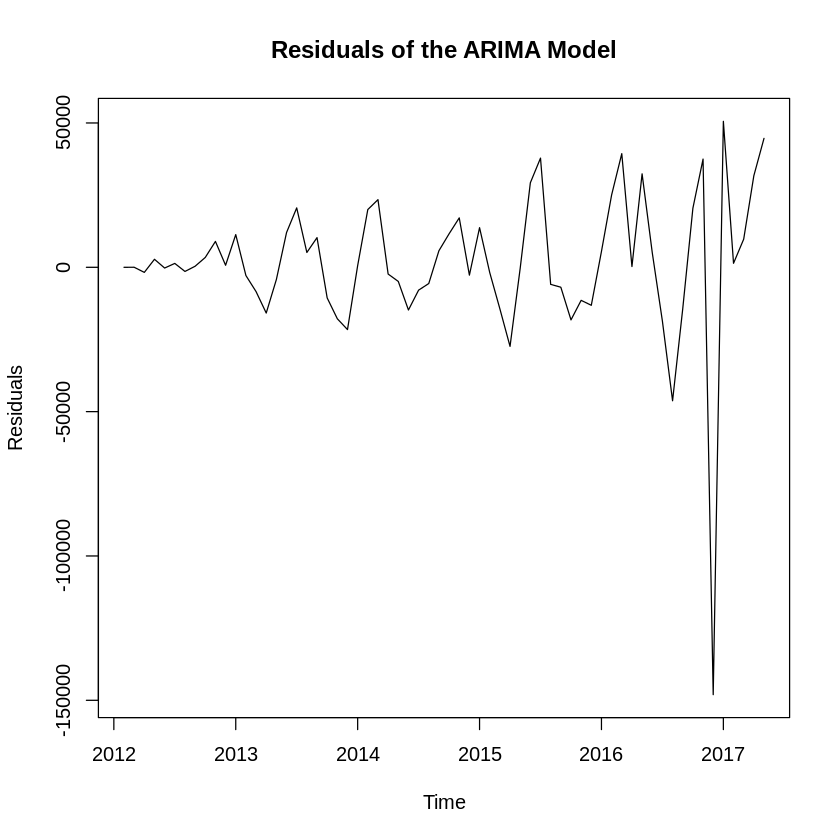

In [ ]:
# Checking residual diagnostics
checkresiduals(arima_model)

# Plotting the residuals
residuals_plot <- residuals(arima_model)
plot(residuals_plot,
     main = "Residuals of the ARIMA Model",
     xlab = "Time",
     ylab = "Residuals")

# Performing Ljung-Box test on residuals
Box.test(residuals_plot, lag = 10, type = "Ljung-Box")

### Residual Diagnostics Analysis
From the output and diagnostic plots:

* Residual Line Plot:
 * Residuals fluctuate around zero, which is a good sign.
* ACF Plot:
 * Most lags are within the confidence bounds, indicating no significant autocorrelation in residuals.
* Histogram:
 * Residuals appear roughly normally distributed, though there may be some skewness.
* Ljung-Box Test:
 * p-value = 0.3467 (> 0.05), suggesting no significant autocorrelation in the residuals. The residuals behave like white noise.

These findings confirm that the ARIMA(2,2,2) model is adequate for this data.

###Statistical Conclusions
* The ARIMA(2,2,2) model adequately fits the data and captures its underlying trend.
* Residuals are white noise, meaning the model captures all patterns in the data effectively.
* Forecasts from the model are reliable within the provided confidence intervals.

#Contextual Conclusions for the Project
###Motivation and Problem Context

The goal was to analyze electric car sales data in the USA and forecast future sales to assist stakeholders in planning inventory and production.

###Key Findings

* Trend Analysis: Sales have shown a steady upward trend over the years, indicating the growing adoption of electric cars.
* Seasonality: The sales exhibit minor seasonality patterns, which are adequately captured in the model.
* Forecasting:
 * The ARIMA(2,2,2) model predicts steady growth in sales over the next 12 months.
 * For example, sales are expected to reach approximately 1.86 million units in May 2018, with a range of 1.22 to 2.50 million units under the 95% confidence interval.

###Implications for Stakeholders

* Manufacturers and suppliers can use these forecasts to align production and inventory management.
* Policymakers can leverage this growth trajectory to support infrastructure development, such as charging stations.